In [1]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
base_path = Path('/content/drive/MyDrive/Solvro 2026/01_przetwarzanie_wizualizacja_danych') # change to path folder with data

# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

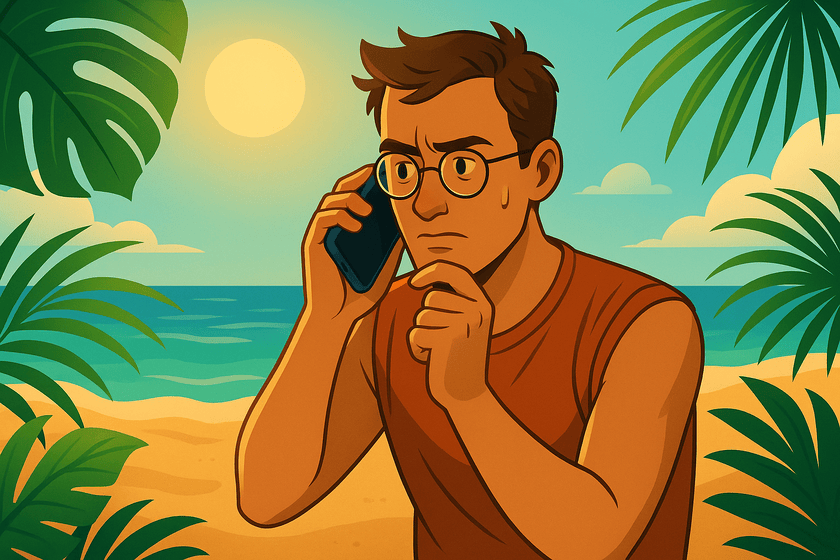

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         


In [3]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')
titanic_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


# 1. Sprawdzenie braków

Najpierw sprawdziłam, które kolumny zawierają braki danych - były to kolumny age, fare, cabin i embarked. Przedstawiłam procentowy brak danych. Najwięcej braków posiadała kolumna cabin - 77%

In [4]:
x, y = titanic_df.shape
#procentowy brak danych
(titanic_df.isna().sum(axis=0)/x * 100).round(2)

,0
Survived,0.00
Pclass,0.00
Name,0.00
Sex,0.00
Age,19.87
SibSp,0.00
Parch,0.00
Ticket,0.00
Fare,11.00
Cabin,77.10


# 2. Uzupełnianie braków

#### Kolumna Age
W przypadku wieku uzupełniłam go zgodnie z jego rozkładem (nie był normalny) natomiast miałam wrażenie, że może to zaburzać wyniki dlatego postanowiłam dodać kolumnę was_age_missing z wartościami binarnymi - aby żadne informacje nie zostały utracone.

In [5]:
#Kolumna was_age_missing
missing_age_vals = titanic_df.Age.isna()
titanic_df['was_age_missing'] = missing_age_vals * 1

In [6]:
#Uzupełnienie kolumny age
def get_column_distribution(df, column):
  return df[column].value_counts(normalize=True)

#rozkład
age_distribution = get_column_distribution(titanic_df, 'Age')
#wartości
age_values = age_distribution.index
#prawdopodobieństwa
age_probs = age_distribution.values

#uzupełnienie
titanic_df.loc[missing_age_vals, 'Age'] = np.random.choice(age_values, size=missing_age_vals.sum(), p=age_probs)

In [7]:
titanic_df['Age'].isna().sum()

np.int64(0)

#### Kolumna Fare
W przypadku kolumny fare(ceny biletu) podejrzewałam wysoki związek pomiędzy klasą, a ceną biletu - korelacja wykazała około -0.5, a zatem nie najwyższą, ale wystarczającą. Sprawdziłam też, że rzeczywiście ceny te się różnią pomiędzy klasami i postanowiłam uzupełnić braki za pomocą mediany występującej w klasie, którą posiadał dany pasażer. Każda osoba ma wpisaną klasę, więc nie ma z tym problemu.

In [8]:
#kolumna Fare
fare_distribution = get_column_distribution(titanic_df, 'Fare')

#korelacje - całkiem duża pomiędzy ceną biletu fare, a klasą
correlation_matrix = titanic_df.corr(numeric_only=True)
correlation_matrix

,Survived,Pclass,Age,SibSp,Parch,Fare,was_age_missing
Survived,1.000000,-0.338481,-0.063034,-0.035322,0.081629,0.266819,-0.092197
Pclass,-0.338481,1.000000,-0.264016,0.083081,0.018443,-0.546866,0.172933
Age,-0.063034,-0.264016,1.000000,-0.225509,-0.176161,0.066783,0.026093
SibSp,-0.035322,0.083081,-0.225509,1.000000,0.414838,0.156443,0.018958
Parch,0.081629,0.018443,-0.176161,0.414838,1.000000,0.226834,-0.124104
Fare,0.266819,-0.546866,0.066783,0.156443,0.226834,1.000000,-0.097719
was_age_missing,-0.092197,0.172933,0.026093,0.018958,-0.124104,-0.097719,1.000000


In [9]:
#klasy między sobą bardzo różnią się względem cen biletów - średnia to najbardziej pokazuje
titanic_df.groupby('Pclass')['Fare'].describe()

,count,mean,std,min,25%,50%,75%,max
Pclass,,,,,,,,
1,194.0,86.771177,81.123003,0.0,31.3302,60.2875,103.19375,512.3292
2,169.0,20.489127,13.171854,0.0,13.0000,14.0000,26.00000,73.5000
3,430.0,13.886074,12.142212,0.0,7.7500,8.0500,15.53750,69.5500


In [10]:
#mediana w poszczególnych klasach
fare_class_median = titanic_df.groupby('Pclass')['Fare'].median()
#zmapowanie wartości fare medianą klas
titanic_df['Pclass'].map(fare_class_median)

#podstawienie mapy tylko na braki
fare_values = titanic_df['Fare'].fillna(titanic_df['Pclass'].map(fare_class_median))
titanic_df['Fare'] = fare_values

In [11]:
fare_values.isna().sum()

np.int64(0)

#### Kolumna Cabin
W przypadku tej kolumny, uważałam że dokładny numerek kabiny nie ma znaczenia, ale ważnym jest czy dana osoba kabinę w ogóle miała. Postanowiłam, więc zamienić to podobnie jak w kolumnie was_age_missing. Usunęłam oryginalną kolumnę i zastąpiłam ją tą z wartościami binarnymi. Korelacja wykazała związek między posiadaniem kabiny a przypisaną klasą. Na koniec usunęłam kolumnę 'Cabin'

In [12]:
missing_cabin_vals = titanic_df.Cabin.isna()
titanic_df['had_cabin'] = 1 - 1 * missing_cabin_vals

In [13]:
titanic_df[['Pclass', 'had_cabin']].corr()

,Pclass,had_cabin
Pclass,1.000000,-0.725541
had_cabin,-0.725541,1.000000


In [14]:
titanic_df = titanic_df.drop('Cabin', axis=1)

In [15]:
titanic_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,was_age_missing,had_cabin
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,0,1
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,0
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,0,1
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,0,0
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,0,1
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,42.0,1,2,W./C. 6607,23.4500,S,1,0


#### Kolumna Embarked
W kolumnie Embarked braki danych to 0.22%, więc uzupełniłam je najczęściej występującą wartością. Była nią wartość 'S', która w zbiorze występuje w około 72% przypadków

In [16]:
titanic_df['Embarked'].describe()

,Embarked
count,889
unique,3
top,S
freq,644


In [17]:
most_common_embarked = titanic_df['Embarked'].mode()[0]
most_common_embarked

'S'

In [18]:
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(most_common_embarked)

# 3. 'Uładnianie' zbioru

Teraz przeszłam do kodowania cech tak by przyszły model mógł je dobrze czytać.
- Cecha Survied to zmienna binarna, **brak zmiany**,
- Cecha Cabin o wartościach [1, 2, 3] to zmienną jakościowa o wartościach całkowitych z tego powodu **brak zmiany**,
- Cecha Name to zmienna z imieniem i nazwiskiem danej osoby, nie uważałam tej informacji za ważną w kontekście rozważanego modelu - **usunięta**,
- Cecha Sex aktualnie posiada wartości 'male' i 'female' - **zmieniona** na
wartości binarne: 0 - female, 1 - male,
- Cecha Age posiadała ważne informacje **brak zmiany**
- Cechy SibSp i Parch - nie widziałam sensu w osobnych kategoriach rozdzielonych na liczbe rodzeństwa i małżonków oraz liczbe dzieci i rodziców na pokładzie. Zrobiłam z nich sumę i nazwałam ją 'family_on_board' - **nowa kolumna**
- Cecha Ticket podobnie jak Name nie uważałam jej za ważną informację **usunięta**
- Cecha Fare **brak zmiany** (rozważałam standaryzację, ale jej nie wdrożyłam)
- Cecha Cabin **zmieniona** w poprzednich krokach została zmodyfikowana na to czy ktoś miał kabinę czy nie miał (brak danych - uproszczenie) - binarna
- Cecha Embarked - nie było tutaj naturalnej hierarchii czy któraś z danych powinna mieć wyższą wartość od innej, więc postawiłam na **kodowanie** one-hot. Miałam również na uwadze to, iż unikalnych wartości w tej kolumnie jest tylko 3.


In [19]:
#usuniecie name
titanic_df = titanic_df.drop('Name', axis=1)

In [20]:
#zmiana sex
is_sex_male = titanic_df['Sex'] == 'male'

titanic_df['Sex'] = is_sex_male * 1
titanic_df['Sex']

,Sex
PassengerId,
1,1
2,0
3,0
4,0
5,1
...,...
887,1
888,0
889,0


In [21]:
#stworzenie family_on_board
titanic_df['family_on_board'] = titanic_df['SibSp'] + titanic_df['Parch']
titanic_df = titanic_df.drop(['SibSp', 'Parch'], axis=1)

In [22]:
#usunięcie Ticket
titanic_df = titanic_df.drop('Ticket', axis=1)

In [23]:
#Embarked
all_embarked = titanic_df.Embarked.value_counts()
all_embarked

,count
Embarked,
S,646
C,168
Q,77


In [24]:
titanic_cleaned = pd.get_dummies(data=titanic_df, prefix='Embarked', columns=['Embarked'], dtype=np.int32) # pass in dataframe and columns to one-hot code
titanic_cleaned

,Survived,Pclass,Sex,Age,Fare,was_age_missing,had_cabin,family_on_board,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,
1,0,3,1,22.0,7.2500,0,0,1,0,0,1
2,1,1,0,38.0,71.2833,0,1,1,1,0,0
3,1,3,0,26.0,7.9250,0,0,0,0,0,1
4,1,1,0,35.0,53.1000,0,1,1,0,0,1
5,0,3,1,35.0,8.0500,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,1,27.0,13.0000,0,0,0,0,0,1
888,1,1,0,19.0,30.0000,0,1,0,0,0,1
889,0,3,0,42.0,23.4500,1,0,3,0,0,1


Na koniec tabela wygląda w ten sposób. Zostały dodane kolumny was_age_missing, had_cabin, Embarked_c, Embarked_Q, Embarked_S.

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |                                                      |
| **Sex**      | Płeć pasażera (1 = mężczyzna, 0 = kobieta).|
| **Age**      | Wiek pasażera w latach.  |
| **Fare**     | Cena biletu. |
| **was_age_missing**  | Czy wiek był podany (1 - nie, 0 - tak) |
| **had_cabin** | Czy pasażer posiadał kabinę (1 - tak, 0 - nie) [dokładniej czy był brak danych kabiny]
| **Embarked_C** | Czy pasażer wsiadł w C = Cherbourg (1- tak, 0 - nie)|
| **Embarked_Q** | Czy pasażer wsiadł w Q = Queenstown (1- tak, 0 - nie)|
| **Embarked_S** | Czy pasażer wsiadł w S = Southampton (1- tak, 0 - nie)|

# 4. Wizualizacje oraz wykrywanie outlierów

Skorzystałam z macierzy korelacji, żeby się zastanowić nad tym jak wizualnie przedstawić moje dane. Najpierw zauważyłam korelacje pomiędzy przeżyciem oraz płcią, a następnie pomiędzy klasą oraz posiadaniem kabiny. W pierwszej kolejności wizualizowałam dane jakościowe.

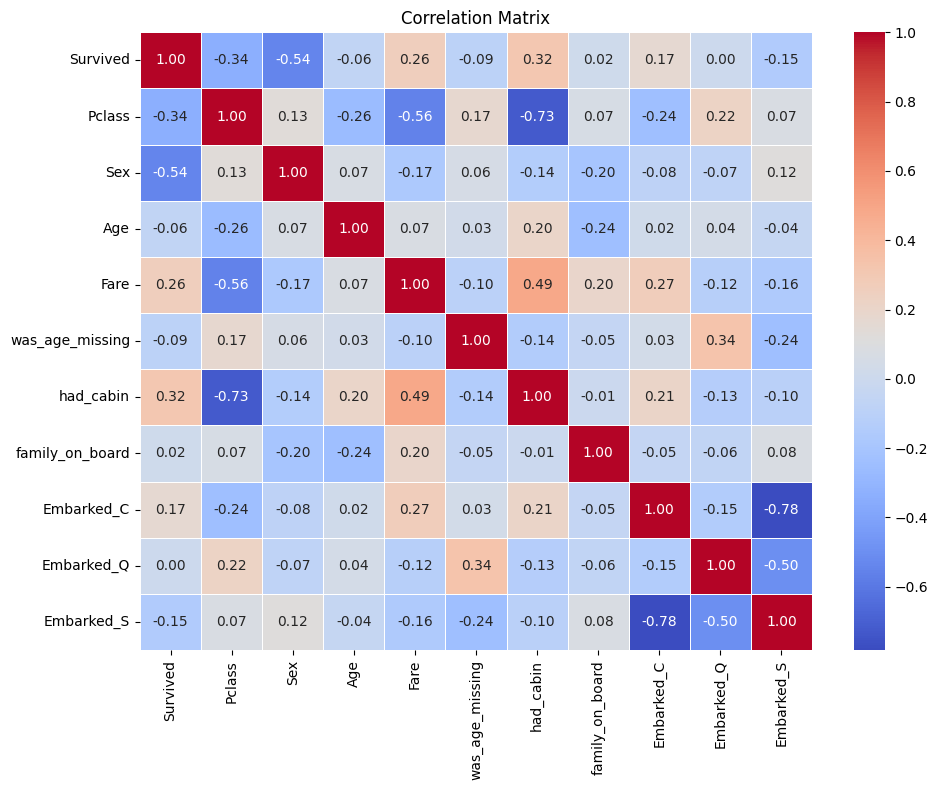

In [25]:
def plot_correlation_matrix(df):
    corr = df.corr(numeric_only=True)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

plot_correlation_matrix(titanic_cleaned)

Poniżej przedstawiono wykres skumulowany przedstawiający ile osób przeżyło z podziałem na płeć. Można zauważyć, że u kobiet przeżyła większość, natomiast nie można tego samego powiedzieć o mężczyznach. Widać, iż byli to gentelmani. Na podstawie wykresu nie stwierdzono outlierów w obu cechach.

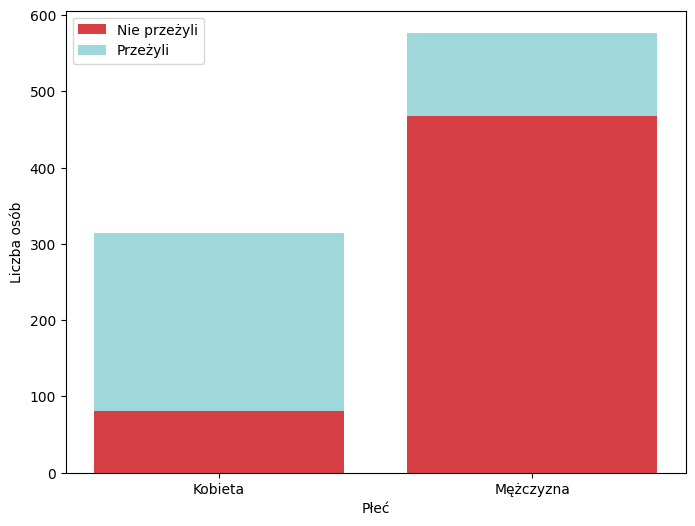

In [27]:
series_0 = titanic_cleaned[titanic_cleaned.Survived == 0].Sex.value_counts()
series_1 = titanic_cleaned[titanic_cleaned.Survived == 1].Sex.value_counts()

sex = [0, 1]

plt.figure(figsize=(8, 6))
plt.bar(sex, series_0.reindex(sex), label='Nie przeżyli', color='#D64045')
plt.bar(sex, series_1.reindex(sex),
        bottom=series_0.reindex(sex),
        label='Przeżyli',
        color='#9ED8DB')

plt.xticks(sex, ['Kobieta', 'Mężczyzna'])
plt.xlabel('Płeć')
plt.ylabel('Liczba osób')
plt.legend()
plt.show()

Wykres przedstawiony poniżej to różnież wykres słupkowy skumulowany, który przedstawia ilość osób posiadającą kabinę z podziałem na klasy. Na jego podstawie stwierdziłam, iż najwięcej osób było w klasie III. Mały odsetek osób w klasie II a także klasie III posiadał kabinę. Klasa I była klasą o najliczniejszej grupie osób posiadajcych kabinę. Outlierów nie stwierdzono. Nawet jeśli mały % osób posiada kabinę to jest to ważna informacja, a nie outlier.

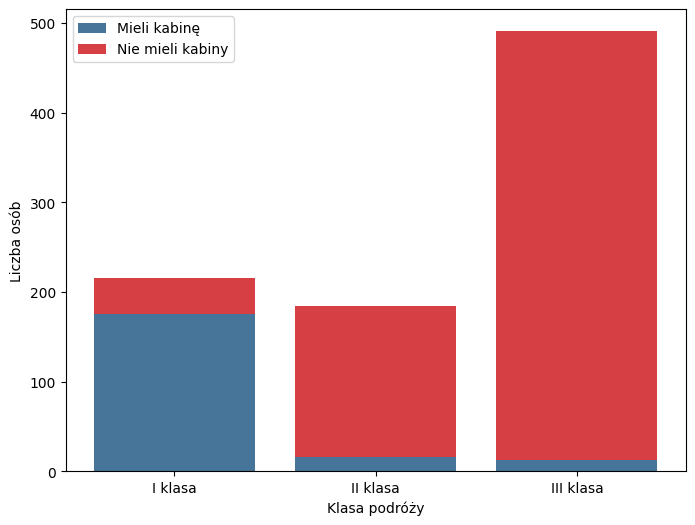

In [28]:
had_cabin = titanic_cleaned[titanic_cleaned.had_cabin == 1].Pclass.value_counts()
hadnt_cabin = titanic_cleaned[titanic_cleaned.had_cabin == 0].Pclass.value_counts()

classes = [1, 2, 3]

plt.figure(figsize=(8, 6))
plt.bar(classes, had_cabin.reindex(classes), label='Mieli kabinę', color='#467599')
plt.bar(classes, hadnt_cabin.reindex(classes),
        bottom=had_cabin.reindex(classes),
        label='Nie mieli kabiny',
        color='#D64045')

plt.xticks(classes, ['I klasa', 'II klasa', 'III klasa'])
plt.xlabel('Klasa podróży')
plt.ylabel('Liczba osób')
plt.legend()
plt.show()

Poniższy wykres przedstawia ile osób wsiadało w danym porcie. Outlierów nie stwierdzono. Najwięcej osób wisadło w Southampton, następnie w Cherbourg oraz najmniej w Queenstown.

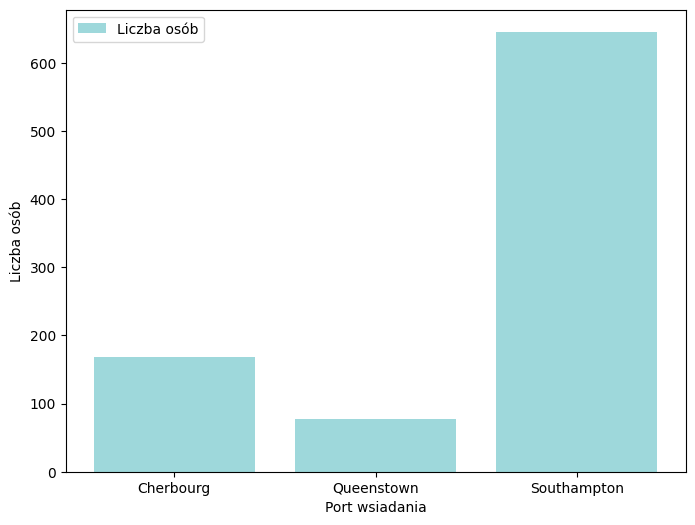

In [39]:
Emb_c = titanic_cleaned.Embarked_C.sum()
Emb_q = titanic_cleaned.Embarked_Q.sum()
Emb_s = titanic_cleaned.Embarked_S.sum()

embarked = ['C', 'Q', 'S']

plt.figure(figsize=(8, 6))
plt.bar(embarked, [Emb_c, Emb_q, Emb_s], label='Liczba osób', color='#9ED8DB')
plt.xticks(embarked, ['Cherbourg', 'Queenstown', 'Southampton'])
plt.xlabel('Port wsiadania')
plt.ylabel('Liczba osób')
plt.legend()
plt.show()

Następnie przedstawiłam ile członków rodziny miały osoby znajdujące się na pokładzie. Zastanawiała mnie wartość 10. Czy rzeczywiście ktoś miał, aż tylu członków na pokładzie, ale wydaje mi się to w granicach zdrowego rozsądku - może ktoś zabrał całą rodzinkę z rodzicami, małżonkiem, rodzeństwem oraz swoimi dziećmi.

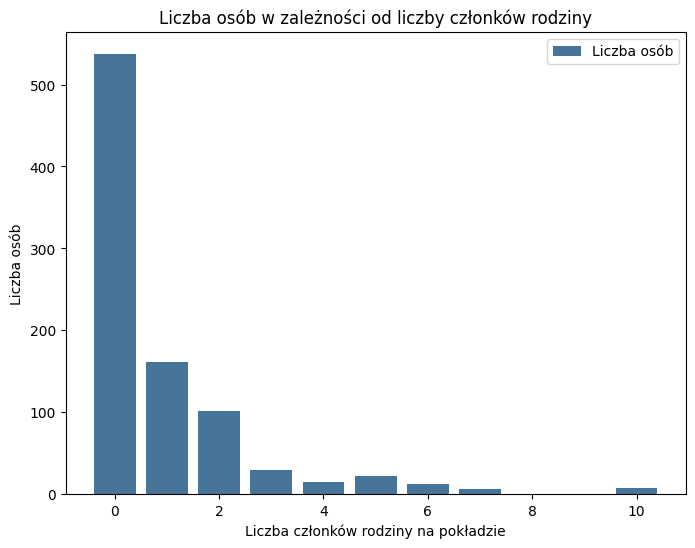

In [30]:
family_count = titanic_cleaned.family_on_board.value_counts().sort_index()

plt.figure(figsize=(8, 6))
plt.bar(family_count.index, family_count.values, color='#467599', label='Liczba osób')

plt.xlabel('Liczba członków rodziny na pokładzie')
plt.ylabel('Liczba osób')
plt.title('Liczba osób w zależności od liczby członków rodziny')
plt.legend()
plt.show()

Poniżej przedstawiam wykres pudełkowy z wiekiem pasażerów. Mediana wieku wynosi trochę mniej niż 30 lat. Pojawiają się outliery natomiast wierzę w to że rzeczywiście na pokładzie mogły być osoby w wieku 70 lub 80 lat. Zostawiam je bez zmian w zbiorze. (Chyba że rozważam model, który nie pozwala na istnienie outlierów - teraz jeszcze nie wiem)

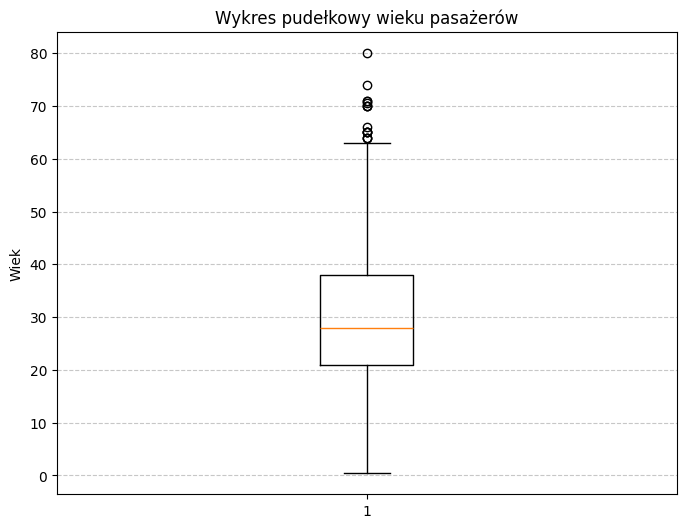

In [31]:
plt.figure(figsize=(8, 6))
plt.boxplot(titanic_cleaned["Age"].dropna())
plt.ylabel("Wiek")
plt.title("Wykres pudełkowy wieku pasażerów")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Na koniec przedstawiam wykres pudełkowy z cenami biletów. Zauważyłam cenę drastycznie odstającą wynoszącą powyżej 500. Decyduję się na zmianę jej na wartość najczęściej występującą. Następnie nadal jest outlierów całkiem dużo, ale zostawiłam je bo nie miałam innego pomysłu. Pozdrawiam.

Sprawdziłam sobie jeszcze rozkład, żeby to ładniej zwizualizować.

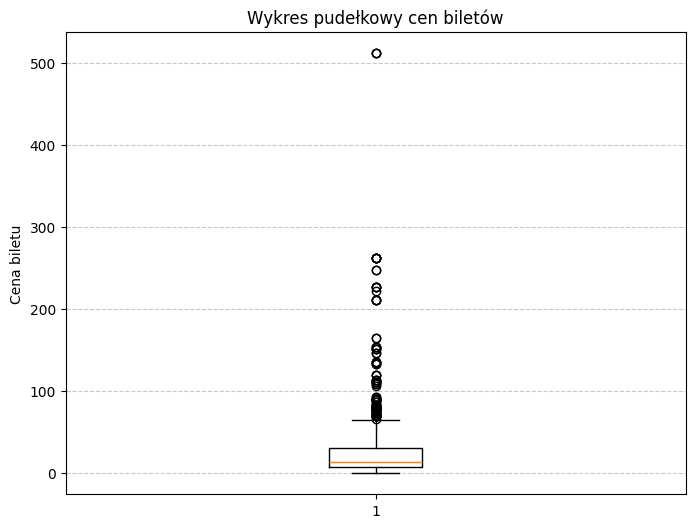

In [32]:
plt.figure(figsize=(8, 6))
plt.boxplot(titanic_cleaned.Fare)
plt.ylabel("Cena biletu")
plt.title("Wykres pudełkowy cen biletów")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [33]:
index_to_fix = titanic_cleaned[titanic_cleaned["Fare"] > 300].index
titanic_cleaned.loc[index_to_fix, "Fare"] = titanic_cleaned["Fare"].median()

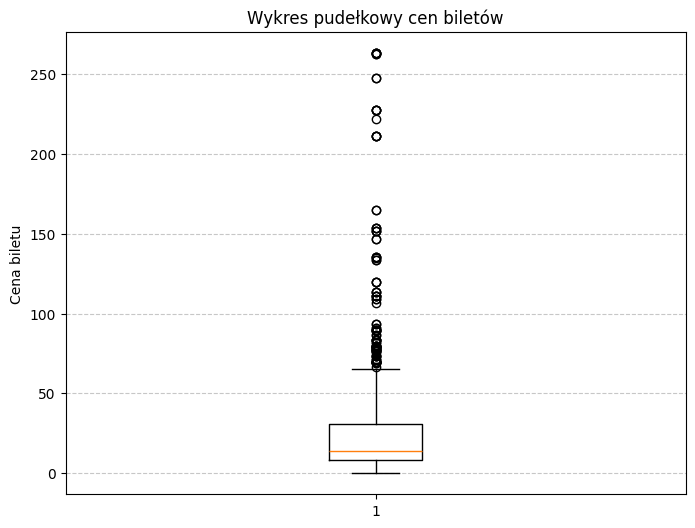

In [34]:
plt.figure(figsize=(8, 6))
plt.boxplot(titanic_cleaned.Fare)
plt.ylabel("Cena biletu")
plt.title("Wykres pudełkowy cen biletów")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

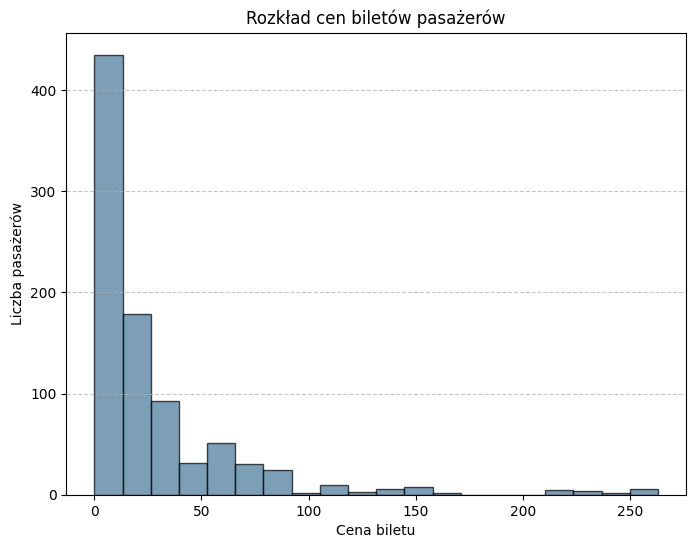

In [37]:
plt.figure(figsize=(8, 6))
plt.hist(titanic_cleaned["Fare"].dropna(), bins=20, color='#467599', edgecolor='black', alpha=0.7)

plt.ylabel("Liczba pasażerów")
plt.xlabel("Cena biletu")
plt.title("Rozkład cen biletów pasażerów")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()